<a href="https://colab.research.google.com/github/jcdevaney/voiceAndGender/blob/main/notebooks/Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway
from scipy.stats import tukey_hsd
from scipy.stats import linregress
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
#from statsmodels.formula.api import ols
from math import sqrt
import seaborn as sns
!pip install statannotations
from statannotations.Annotator import Annotator
!git clone https://github.com/jcdevaney/voiceAndGender.git

Cloning into 'voiceAndGender'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 2), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 1.60 MiB | 7.67 MiB/s, done.
Resolving deltas: 100% (2/2), done.


## Import/organize data

In [2]:
df_AS = pd.read_csv('/content/voiceAndGender/data/AudioFeatures_AudioSetSubset.csv')
df_MC = pd.read_csv('/content/voiceAndGender/data/AudioFeatures_MusicCapsSubset.csv')
df_LM = pd.read_csv('/content/voiceAndGender/data/AudioFeatures_MusicLM.csv')

In [3]:
# audio set
# 0 = male singing
# 1 = female singing
# 2 = male and female singing
# 3 = male speech
# 4 = female speech
# 5 = male and female speech
# 6 = other

df_maleASsing = df_AS[df_AS["gender_label"] == 0]
df_femaleASsing = df_AS[df_AS["gender_label"] == 1]
df_bothMCsing  = df_AS[df_AS["gender_label"] == 2]

df_maleASspeech = df_AS[df_AS["gender_label"] == 3]
df_femaleASspeech = df_AS[df_AS["gender_label"] == 4]
df_bothASspeech  = df_AS[df_AS["gender_label"] == 5]

# music caps
# 0 - male; 1 - female; 2 - both

df_maleMC = df_MC[df_MC["gender_label"] == 0]
df_femaleMC = df_MC[df_MC["gender_label"] == 1]
df_bothMC = df_MC[df_MC["gender_label"] == 2]

df_maleLM = df_LM[df_LM["gender_label"] == 0]
df_femaleLM = df_LM[df_LM["gender_label"] == 1]
df_bothLM = df_LM[df_LM["gender_label"] == 2]

In [4]:
# drop nans
df_maleASspeech = df_maleASspeech.dropna(axis=0)
df_femaleASspeech = df_femaleASspeech.dropna(axis=0)

df_maleASsing = df_maleASsing.dropna(axis=0)
df_femaleASsing = df_femaleASsing.dropna(axis=0)

df_maleMC = df_maleMC.dropna(axis=0)
df_femaleMC = df_femaleMC.dropna(axis=0)

df_maleLM = df_maleLM.dropna(axis=0)
df_femaleLM = df_femaleLM.dropna(axis=0)

In [5]:
# reduce to 401 samples per label to balance the data
df_femaleASspeech=df_femaleASspeech.sample(n=min(len(df_femaleASspeech), 401), random_state=42).reset_index(drop=True)
df_maleASspeech=df_maleASspeech.sample(n=min(len(df_maleASspeech), 401), random_state=42).reset_index(drop=True)

df_femaleASsing=df_femaleASsing.sample(n=min(len(df_femaleASsing), 401), random_state=42).reset_index(drop=True)
df_maleASsing=df_maleASsing.sample(n=min(len(df_maleASsing), 401), random_state=42).reset_index(drop=True)

df_femaleMC=df_femaleMC.sample(n=min(len(df_femaleMC), 401), random_state=42).reset_index(drop=True)
df_maleMC=df_maleMC.sample(n=min(len(df_maleMC), 401), random_state=42).reset_index(drop=True)

df_femaleLM=df_femaleLM.sample(n=min(len(df_femaleLM), 401), random_state=42).reset_index(drop=True)
df_maleLM=df_maleLM.sample(n=min(len(df_maleLM), 401), random_state=42).reset_index(drop=True)

In [6]:
# uncomment to create sampleSubset.csv

# idDF = pd.DataFrame({
#     'femaleASspeech': df_femaleASspeech.ytid,
#     'maleASspeech': df_maleASspeech.ytid,
#     'femaleASsing': df_femaleASsing.ytid,
#     'maleASsing': df_maleASsing.ytid,
#     'femaleMC': df_femaleMC.ytid,
#     'maleMC': df_maleMC.ytid,
#     'femaleLM': df_femaleLM.name,
#     'maleLM': df_maleLM.name,
# })
# idDF.to_csv('/content/sampleSubset.csv')

In [7]:
# Feature  Value			       Delta
# F0		   Pitch height		   Emphasis through pitch variation
# SC		   Chest/head voice	 Brightness stability
# MFCC     Vowels			       Vowel stability
# HNR	     Breathiness
# RMS			 		               Emphasis through energy variation

f0col = 'F0 Mean (Hz)'
SCcol = 'Spectral Centroid Mean (Hz)'
HNRcol = 'HNR Mean'
RMSdeltaCol = 'RMS Delta Mean'
F0deltaCol = 'F0 Delta Mean (Hz)'
SCdeltaCol = 'Spectral Centroid Delta Mean (Hz)'

# F0 Stats

In [8]:
def printf0stats(df, gender, dataset):
      # Quantile-based Filtering
      q1 = df['fmin (Hz)'].quantile(0.01)
      q99 = df['fmin (Hz)'].quantile(0.99)
      df_filtered = df[(df['fmin (Hz)'] >= q1) & (df['fmin (Hz)'] <= q99)]


      # Quantile-based Filtering
      q5 = df['fmin (Hz)'].quantile(0.05)
      q95 = df['fmin (Hz)'].quantile(0.95)
      df_filtered2 = df[(df['fmin (Hz)'] >= q5) & (df['fmin (Hz)'] <= q95)]

      # Z-score Method
      df['z_score'] = (df['fmin (Hz)'] - df['fmin (Hz)'].mean()) / df['fmin (Hz)'].std()
      df_filtered_z = df[(df['z_score'] >= -3) & (df['z_score'] <= 3)]

      # IQR Method
      Q1 = df['fmin (Hz)'].quantile(0.25)
      Q3 = df['fmin (Hz)'].quantile(0.75)
      IQR = Q3 - Q1
      df_iqr = df[(df['fmin (Hz)'] >= Q1 - 1.5*IQR) & (df['fmin (Hz)'] <= Q3 + 1.5*IQR)]

      print(dataset)
      print(gender + ' min:' + str(np.min(df['fmin (Hz)'])))
      print(gender + ' max:' + str(np.max(df['fmin (Hz)'])))
      print(gender + ' Quartile (0.01) min:' + str(np.min(df_filtered['fmin (Hz)'])))
      print(gender + ' Quartile (0.99) max:' + str(np.max(df_filtered['fmin (Hz)'])))
      print(gender + ' Quartile (0.05) min:' + str(np.min(df_filtered2['fmin (Hz)'])))
      print(gender + ' Quartile (0.95) max:' + str(np.max(df_filtered2['fmin (Hz)'])))
      print(gender + ' Z-Score min:' + str(np.min(df_filtered_z['fmin (Hz)'])))
      print(gender + ' Z-Score max:' + str(np.max(df_filtered_z['fmin (Hz)'])))
      print(gender + ' IQR min:' + str(np.min(df_iqr['fmin (Hz)'])))
      print(gender + ' IQR max:' + str(np.max(df_iqr['fmin (Hz)'])))
      print()


In [9]:
printf0stats(df_femaleASspeech, 'Female','AS Speech')
printf0stats(df_maleASspeech, 'Male','AS Speech')

printf0stats(df_femaleASsing, 'Female','AS Singing')
printf0stats(df_maleASsing, 'Male','AS Singing')

printf0stats(df_femaleMC, 'Female','MusicCaps')
printf0stats(df_maleMC, 'Male','MusicCaps')

printf0stats(df_femaleLM, 'Female','Music LM')
printf0stats(df_maleLM, 'Male','Music LM')

AS Speech
Female min:32.70319566257483
Female max:706.5721360397714
Female Quartile (0.01) min:72.57293509250917
Female Quartile (0.99) max:398.84739550836855
Female Quartile (0.05) min:96.87324609557632
Female Quartile (0.95) max:254.17759331190007
Female Z-Score min:32.70319566257483
Female Z-Score max:339.2863815897469
Female IQR min:76.88834637984607
Female IQR max:261.6255653005986

AS Speech
Male min:34.64782887210901
Male max:1471.453646587776
Male Quartile (0.01) min:48.15764862732369
Male Quartile (0.99) max:816.3400229083522
Male Quartile (0.05) min:80.52471328
Male Quartile (0.95) max:309.33502415691686
Male Z-Score min:34.64782887210901
Male Z-Score max:573.9149106968484
Male IQR min:34.64782887210901
Male IQR max:248.37216905734883

AS Singing
Female min:54.05513292
Female max:1446.174953670991
Female Quartile (0.01) min:71.73936383710603
Female Quartile (0.99) max:422.5640958224419
Female Quartile (0.05) min:157.37105256787842
Female Quartile (0.95) max:343.2286994458844


## Violin Plots with Mann-Whitney Tests
### (Figures 3–6)

In [10]:
# The code in this cell generated with assistance of GPT 5.5.

def _hodges_lehmann(a, b):
    # median of all pairwise differences (b_i - a_j)
    diffs = np.subtract.outer(np.asarray(b), np.asarray(a)).ravel()
    return np.median(diffs)

def _bootstrap_ci(func, a, b, n_boot=2000, alpha=0.05, rng=None):
    rng = np.random.default_rng(rng)
    a = np.asarray(a); b = np.asarray(b)
    n1, n2 = len(a), len(b)
    stats = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        a_s = a[rng.integers(0, n1, n1)]
        b_s = b[rng.integers(0, n2, n2)]
        stats[i] = func(a_s, b_s)
    lo = np.percentile(stats, 100*alpha/2)
    hi = np.percentile(stats, 100*(1-alpha/2))
    return float(lo), float(hi)

def _fmt_p(p):
    return "< .001" if p < 0.001 else f"= {p:.3f}"

def violinPlot(col, x, y, xlabel, ylabel, max, min,
                      ci_alpha=0.05, units=""):

    # initialize datafram
    dfPlotall = pd.DataFrame({
        'AS1M': df_maleASspeech[col],
        'AS1F': df_femaleASspeech[col],
        'AS2M': df_maleASsing[col],
        'AS2F': df_femaleASsing[col],
        'MCM' : df_maleMC[col],
        'MCF' : df_femaleMC[col],
        'LMM' : df_maleLM[col],
        'LMF' : df_femaleLM[col]
    })

    # copy for plotting only
    dfPlotall_plot = dfPlotall.clip(lower=min, upper=max)

    # long versions for plotting
    df_long_plot = pd.melt(dfPlotall_plot, var_name=x, value_name=y)

    order = ['AS1M', 'AS1F', 'AS2M', 'AS2F', 'MCM', 'MCF', 'LMM', 'LMF']
    custom_colors = ["#82e0aa", "#82e0aa", "#2ecc71", "#2ecc71",
                     "#239b56", "#239b56", "#2e86c1", "#2e86c1"]

    ax = sns.violinplot(
        data=df_long_plot, x=x, y=y,
        hue=x, order=order, hue_order=order,
        palette=custom_colors, legend=False
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(range(len(order)))

    ax.set_xticklabels([
        "AS Speech\nMale", "AS Speech\nFemale",
        "AS Singing\nMale", "AS Singing\nFemale",
        "MC Singing\nMale", "MC Singing\nFemale",
        "LM Singing\nMale", "LM Singing\nFemale"
    ])

    plt.xticks(rotation=45, ha='center')

    # pairs to compare
    pairs=[('AS1M', 'AS1F'), ('AS2M', 'AS2F'), ('MCM', 'MCF'), ('LMM', 'LMF')]

    annotator = Annotator(ax, pairs, data=df_long_plot, x=x, y=y, order=order, verbose=0)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=0)
    annotator.apply_and_annotate()

    # -------- statistics on *full data* (not clipped) --------
    rows, pairwise_summaries = [], []
    for a, b in pairs:
        a_vals = dfPlotall[a].dropna().to_numpy()
        b_vals = dfPlotall[b].dropna().to_numpy()
        n1, n2 = len(a_vals), len(b_vals)
        N_total = n1 + n2

        row = {'pair': f'{a} vs {b}', 'n1': n1, 'n2': n2, 'N_total': N_total,
               'U': np.nan, 'z': np.nan, 'p': np.nan, 'p_fmt': None,
               'cliffs_delta': np.nan, 'rank_biserial': np.nan, 'r': np.nan,
               'mean_diff': np.nan, 'mean_CI_low': np.nan, 'mean_CI_high': np.nan,
               'median_diff': np.nan, 'median_CI_low': np.nan, 'median_CI_high': np.nan,
               'HL_shift': np.nan, 'HL_CI_low': np.nan, 'HL_CI_high': np.nan}

        if n1 > 0 and n2 > 0:
            res = mannwhitneyu(a_vals, b_vals, alternative='two-sided')
            U = float(res.statistic)
            p = float(res.pvalue)

            denom = n1 * n2
            cliffs_delta  = (2 * U) / denom - 1.0
            rank_biserial = 1.0 - (2 * U) / denom

            mean_U = denom / 2.0
            sd_U   = sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
            z      = (U - mean_U) / sd_U
            r_from_z = abs(z) / sqrt(N_total)

            mean_diff = float(np.mean(b_vals) - np.mean(a_vals))
            md_lo, md_hi = _bootstrap_ci(lambda aa,bb: np.mean(bb)-np.mean(aa), a_vals, b_vals, alpha=ci_alpha)

            median_diff = float(np.median(b_vals) - np.median(a_vals))
            med_lo, med_hi = _bootstrap_ci(lambda aa,bb: np.median(bb)-np.median(aa), a_vals, b_vals, alpha=ci_alpha)

            hl = float(_hodges_lehmann(a_vals, b_vals))
            hl_lo, hl_hi = _bootstrap_ci(_hodges_lehmann, a_vals, b_vals, alpha=ci_alpha)

            row.update({
                'U': U, 'z': z, 'p': p, 'p_fmt': _fmt_p(p),
                'cliffs_delta': cliffs_delta, 'rank_biserial': rank_biserial, 'r': r_from_z,
                'mean_diff': mean_diff, 'mean_CI_low': md_lo, 'mean_CI_high': md_hi,
                'median_diff': median_diff, 'median_CI_low': med_lo, 'median_CI_high': med_hi,
                'HL_shift': hl, 'HL_CI_low': hl_lo, 'HL_CI_high': hl_hi
            })

            units_str = f" {units}" if units else ""
            apa = (f"{a} vs {b}: U = {U:,.0f}, z = {z:.2f}, p {row['p_fmt']}, "
                   f"r = {r_from_z:.2f}; median difference = {median_diff:.2f}{units_str}, "
                   f"95% CI [{med_lo:.2f}, {med_hi:.2f}{units_str}].")
            pairwise_summaries.append(apa)

        rows.append(row)

    stats_df = pd.DataFrame(rows)
    return ax, stats_df, pairwise_summaries



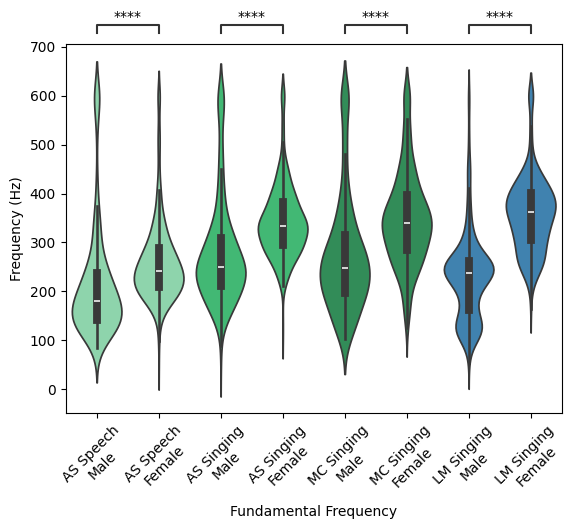

In [11]:
axF0, stats_dfF0, pairwise_summariesF0 = violinPlot(f0col, 'Condition', 'Frequency', 'Fundamental Frequency', 'Frequency (Hz)',600,50)

In [12]:
print('F0 Stats Table')
stats_dfF0

F0 Stats Table


,pair,n1,n2,N_total,U,z,p,p_fmt,cliffs_delta,rank_biserial,r,mean_diff,mean_CI_low,mean_CI_high,median_diff,median_CI_low,median_CI_high,HL_shift,HL_CI_low,HL_CI_high
0,AS1M vs AS1F,401,401,802,43162.0,-11.352216,7.243252e-30,< .001,-0.463163,0.463163,0.400861,30.449202,8.419329,51.243826,61.436016,51.144509,71.906446,60.613327,51.627446,69.030287
1,AS2M vs AS2F,401,401,802,38734.0,-12.702099,5.767689e-37,< .001,-0.518237,0.518237,0.448527,60.536766,42.389018,78.198852,83.996554,72.607399,92.775080,78.668514,68.506985,88.731911
2,MCM vs MCF,401,401,802,42751.0,-11.477510,1.714396e-30,< .001,-0.468274,0.468274,0.405285,72.533279,51.280979,92.938578,91.786439,74.748334,105.095341,86.624042,73.879486,99.781286
3,LMM vs LMF,401,401,802,18631.0,-18.830531,4.257077e-79,< .001,-0.768273,0.768273,0.664929,130.738769,118.456148,142.787585,124.349094,110.712508,133.318271,131.807360,121.951140,141.028167


In [13]:
print('F0 Pairwise Summaires')
pairwise_summariesF0

F0 Pairwise Summaires


['AS1M vs AS1F: U = 43,162, z = -11.35, p < .001, r = 0.40; median difference = 61.44, 95% CI [51.14, 71.91].',
 'AS2M vs AS2F: U = 38,734, z = -12.70, p < .001, r = 0.45; median difference = 84.00, 95% CI [72.61, 92.78].',
 'MCM vs MCF: U = 42,751, z = -11.48, p < .001, r = 0.41; median difference = 91.79, 95% CI [74.75, 105.10].',
 'LMM vs LMF: U = 18,631, z = -18.83, p < .001, r = 0.66; median difference = 124.35, 95% CI [110.71, 133.32].']

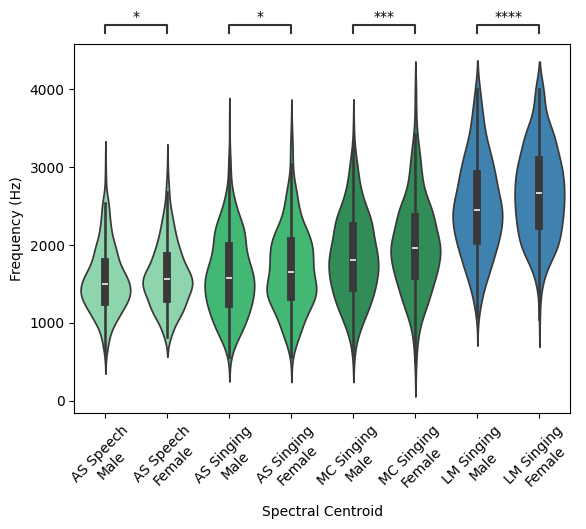

In [14]:
axSC, stats_dfSC, pairwise_summariesSC = violinPlot(SCcol, 'Condition', 'Spectral Centroid', 'Spectral Centroid', 'Frequency (Hz)',4000,50)

In [15]:
print('Spectral Centroid Stats Table')
stats_dfSC

Spectral Centroid Stats Table


,pair,n1,n2,N_total,U,z,p,p_fmt,cliffs_delta,rank_biserial,r,mean_diff,mean_CI_low,mean_CI_high,median_diff,median_CI_low,median_CI_high,HL_shift,HL_CI_low,HL_CI_high
0,AS1M vs AS1F,401,401,802,73773.0,-2.020404,0.043357,= 0.043,-0.082431,0.082431,0.071343,54.709738,-3.186976,113.418446,62.654197,-5.653706,135.602063,57.170975,1.189605,113.557239
1,AS2M vs AS2F,401,401,802,73953.0,-1.965531,0.049370,= 0.049,-0.080192,0.080192,0.069405,76.968048,1.735266,151.718884,70.830407,-18.755635,179.477490,74.490555,0.152969,150.360986
2,MCM vs MCF,401,401,802,69045.0,-3.461742,0.000537,< .001,-0.141237,0.141237,0.122238,146.728838,66.802329,226.279038,151.466244,52.373911,243.677250,140.534518,57.147137,221.097195
3,LMM vs LMF,401,401,802,66012.0,-4.386357,0.000012,< .001,-0.178960,0.178960,0.154888,194.445059,116.261079,281.232629,214.379635,99.713679,329.016495,198.860673,104.051113,283.730304


In [16]:
print('Spectral Centroid Pairwise Summaires')
pairwise_summariesSC

Spectral Centroid Pairwise Summaires


['AS1M vs AS1F: U = 73,773, z = -2.02, p = 0.043, r = 0.07; median difference = 62.65, 95% CI [-5.65, 135.60].',
 'AS2M vs AS2F: U = 73,953, z = -1.97, p = 0.049, r = 0.07; median difference = 70.83, 95% CI [-18.76, 179.48].',
 'MCM vs MCF: U = 69,045, z = -3.46, p < .001, r = 0.12; median difference = 151.47, 95% CI [52.37, 243.68].',
 'LMM vs LMF: U = 66,012, z = -4.39, p < .001, r = 0.15; median difference = 214.38, 95% CI [99.71, 329.02].']

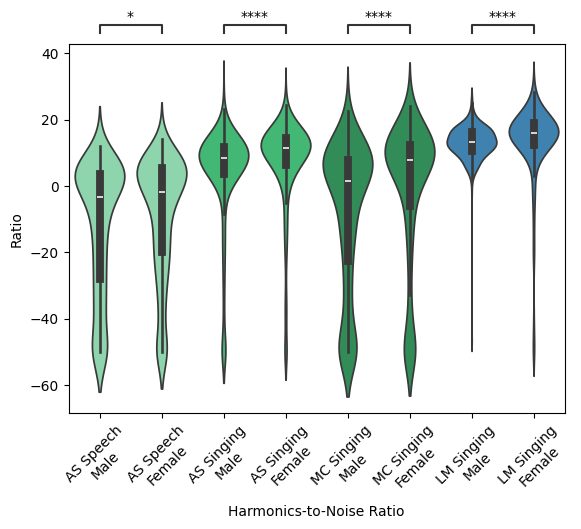

In [17]:
axHNR, stats_dfHNR, pairwise_summariesHNR = violinPlot(HNRcol, 'Condition', 'HNR', 'Harmonics-to-Noise Ratio', 'Ratio',50,-50)

In [18]:
print('HNR Stats Table')
stats_dfHNR

HNR Stats Table


,pair,n1,n2,N_total,U,z,p,p_fmt,cliffs_delta,rank_biserial,r,mean_diff,mean_CI_low,mean_CI_high,median_diff,median_CI_low,median_CI_high,HL_shift,HL_CI_low,HL_CI_high
0,AS1M vs AS1F,401,401,802,72060.0,-2.542615,1.100745e-02,= 0.011,-0.103737,0.103737,0.089783,4.195180,0.549069,7.680975,1.606182,-2.096378,5.425411,2.039517,0.529361,3.679336
1,AS2M vs AS2F,401,401,802,59495.0,-6.373075,1.854594e-10,< .001,-0.260017,0.260017,0.225041,4.340728,1.284254,7.430965,3.068075,2.090503,4.007508,2.864247,2.011169,3.687101
2,MCM vs MCF,401,401,802,58594.5,-6.647594,2.982306e-11,< .001,-0.271217,0.271217,0.234735,6.256123,1.385463,11.132758,6.395559,4.202030,8.661575,5.778502,4.098801,7.662144
3,LMM vs LMF,401,401,802,58656.0,-6.628846,3.386717e-11,< .001,-0.270452,0.270452,0.234073,0.067824,-1.435196,1.473134,2.665456,1.707625,3.341535,2.388151,1.701699,3.069661


In [19]:
print('HNR Pairwise Summaires')
pairwise_summariesHNR

HNR Pairwise Summaires


['AS1M vs AS1F: U = 72,060, z = -2.54, p = 0.011, r = 0.09; median difference = 1.61, 95% CI [-2.10, 5.43].',
 'AS2M vs AS2F: U = 59,495, z = -6.37, p < .001, r = 0.23; median difference = 3.07, 95% CI [2.09, 4.01].',
 'MCM vs MCF: U = 58,594, z = -6.65, p < .001, r = 0.23; median difference = 6.40, 95% CI [4.20, 8.66].',
 'LMM vs LMF: U = 58,656, z = -6.63, p < .001, r = 0.23; median difference = 2.67, 95% CI [1.71, 3.34].']

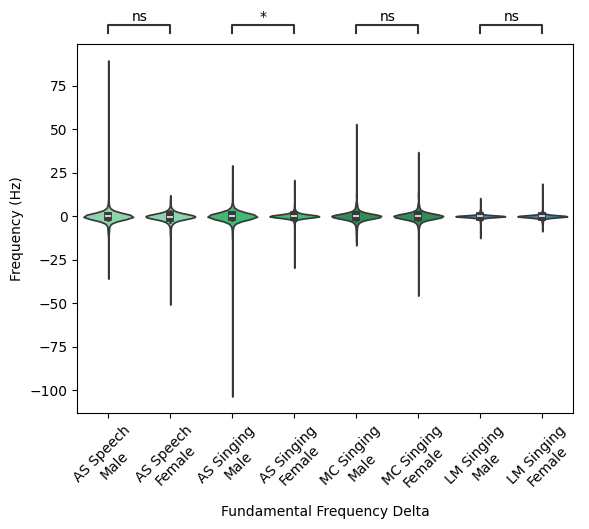

In [20]:
axF0Delta, stats_dfF0Delta, pairwise_summariesF0Delta = violinPlot(F0deltaCol, 'Condition', 'Fundamental Frequency Delta', 'Fundamental Frequency Delta', 'Frequency (Hz)',100,-100)

In [21]:
print('F0 Delta Stats Table')
stats_dfF0Delta

F0 Delta Stats Table


,pair,n1,n2,N_total,U,z,p,p_fmt,cliffs_delta,rank_biserial,r,mean_diff,mean_CI_low,mean_CI_high,median_diff,median_CI_low,median_CI_high,HL_shift,HL_CI_low,HL_CI_high
0,AS1M vs AS1F,401,401,802,81697.0,0.395240,0.692778,= 0.693,0.016126,-0.016126,0.013956,-0.452197,-1.153433,0.151430,-0.045384,-0.164284,0.099915,-0.030559,-0.186318,0.123137
1,AS2M vs AS2F,401,401,802,73206.0,-2.193255,0.028300,= 0.028,-0.089483,0.089483,0.077447,0.542360,-0.026224,1.210278,0.069442,-0.005038,0.158423,0.125346,0.016194,0.251480
2,MCM vs MCF,401,401,802,80945.0,0.165992,0.868283,= 0.868,0.006772,-0.006772,0.005861,-0.268411,-0.866566,0.271928,-0.020776,-0.129763,0.084891,-0.013682,-0.154235,0.142526
3,LMM vs LMF,401,401,802,80658.0,0.078499,0.937552,= 0.938,0.003203,-0.003203,0.002772,-0.000560,-0.195227,0.202343,-0.001215,-0.053550,0.037122,-0.002347,-0.068489,0.066041


In [22]:
print('F0 Delta Pairwise Summaires')
pairwise_summariesF0Delta

F0 Delta Pairwise Summaires


['AS1M vs AS1F: U = 81,697, z = 0.40, p = 0.693, r = 0.01; median difference = -0.05, 95% CI [-0.16, 0.10].',
 'AS2M vs AS2F: U = 73,206, z = -2.19, p = 0.028, r = 0.08; median difference = 0.07, 95% CI [-0.01, 0.16].',
 'MCM vs MCF: U = 80,945, z = 0.17, p = 0.868, r = 0.01; median difference = -0.02, 95% CI [-0.13, 0.08].',
 'LMM vs LMF: U = 80,658, z = 0.08, p = 0.938, r = 0.00; median difference = -0.00, 95% CI [-0.05, 0.04].']

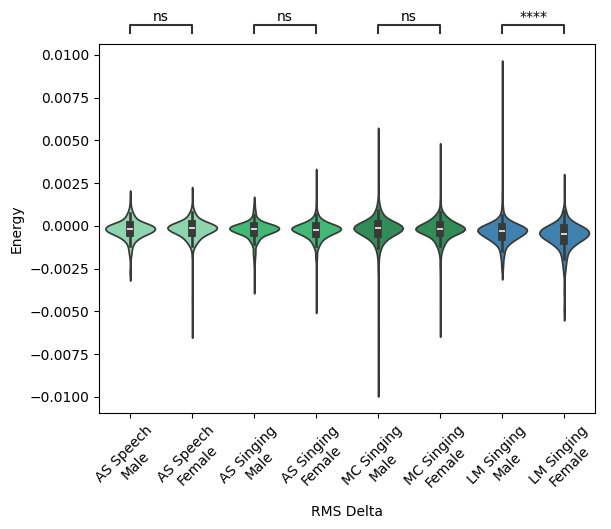

In [23]:
axRMSDelta, stats_dfRMSDelta, pairwise_summariesRMSDelta = violinPlot(RMSdeltaCol, 'Condition', 'RMS Delta', 'RMS Delta', 'Energy',0.5,-0.5)

In [24]:
print('RMS Delta Stats Table')
stats_dfRMSDelta

RMS Delta Stats Table


,pair,n1,n2,N_total,U,z,p,p_fmt,cliffs_delta,rank_biserial,r,mean_diff,mean_CI_low,mean_CI_high,median_diff,median_CI_low,median_CI_high,HL_shift,HL_CI_low,HL_CI_high
0,AS1M vs AS1F,401,401,802,76758.0,-1.110422,0.266883,= 0.267,-0.045304,0.045304,0.039210,0.000007,-0.000080,0.000092,0.000054,-0.000032,0.000115,0.000034,-0.000026,0.000091
1,AS2M vs AS2F,401,401,802,82869.0,0.752526,0.451826,= 0.452,0.030703,-0.030703,0.026573,-0.000009,-0.000083,0.000069,-0.000030,-0.000082,0.000029,-0.000020,-0.000075,0.000030
2,MCM vs MCF,401,401,802,81680.0,0.390058,0.696607,= 0.697,0.015914,-0.015914,0.013773,0.000020,-0.000083,0.000130,-0.000033,-0.000092,0.000042,-0.000013,-0.000077,0.000051
3,LMM vs LMF,401,401,802,94292.0,4.234846,0.000023,< .001,0.172779,-0.172779,0.149538,-0.000242,-0.000360,-0.000135,-0.000203,-0.000274,-0.000104,-0.000156,-0.000224,-0.000085


In [25]:
print('RMS Delta Pairwise Summaires')
pairwise_summariesRMSDelta

RMS Delta Pairwise Summaires


['AS1M vs AS1F: U = 76,758, z = -1.11, p = 0.267, r = 0.04; median difference = 0.00, 95% CI [-0.00, 0.00].',
 'AS2M vs AS2F: U = 82,869, z = 0.75, p = 0.452, r = 0.03; median difference = -0.00, 95% CI [-0.00, 0.00].',
 'MCM vs MCF: U = 81,680, z = 0.39, p = 0.697, r = 0.01; median difference = -0.00, 95% CI [-0.00, 0.00].',
 'LMM vs LMF: U = 94,292, z = 4.23, p < .001, r = 0.15; median difference = -0.00, 95% CI [-0.00, -0.00].']

# Logistic Regression
### (Figure7)

In [26]:
def logisticRegressionAll (male_df, female_df, f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,scale):

    df1 = pd.DataFrame (male_df[[f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,'MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC Delta1', 'MFCC Delta2', 'MFCC Delta3',
       'MFCC Delta4', 'MFCC Delta5', 'MFCC Delta6', 'MFCC Delta7',
       'MFCC Delta8', 'MFCC Delta9', 'MFCC Delta10', 'MFCC Delta11',
       'MFCC Delta12']])
    df1['gender'] = 0

    df2 = pd.DataFrame (female_df[[f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,'MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6','MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12','MFCC Delta1', 'MFCC Delta2', 'MFCC Delta3',
       'MFCC Delta4', 'MFCC Delta5', 'MFCC Delta6', 'MFCC Delta7',
       'MFCC Delta8', 'MFCC Delta9', 'MFCC Delta10', 'MFCC Delta11',
       'MFCC Delta12']])
    df2['gender'] = 1

    df = pd.concat([df1, df2])

    # features and target
    X = df[[f0col, SCcol, HNRcol,
            'MFCC1','MFCC2','MFCC3','MFCC4','MFCC5','MFCC6',
            'MFCC7','MFCC8','MFCC9','MFCC10','MFCC11','MFCC12']]
    y = df['gender'].astype(int)

    # OPTIONAL: standardize predictors (recommended when scales differ a lot)

    if scale:
      print('Scaled!')
      scaler = StandardScaler()
      X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    # add intercept
    X = sm.add_constant(X)

    # logistic regression
    logit_model = sm.Logit(y, X)
    logit_res = logit_model.fit()
    print(logit_res.summary())

    # predicted probabilities and hard labels (0.5 threshold)
    p_hat = logit_res.predict(X)
    y_hat = (p_hat >= 0.5).astype(int)

    # odds ratio
    params = logit_res.params
    df_OR = logit_res.conf_int()
    df_OR['OR'] = np.exp(params)
    df_OR.columns = ['2.5%', '97.5%', 'OR']
    df_OR['2.5%'] = np.exp(df_OR['2.5%'])
    df_OR['97.5%'] = np.exp(df_OR['97.5%'])

    print(df_OR)





In [27]:
logisticRegressionAll(df_maleASspeech, df_femaleASspeech, f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,0)

Optimization terminated successfully.
         Current function value: 0.504146
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                  802
Model:                          Logit   Df Residuals:                      786
Method:                           MLE   Df Model:                           15
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.2727
Time:                        21:16:24   Log-Likelihood:                -404.33
converged:                       True   LL-Null:                       -555.90
Covariance Type:            nonrobust   LLR p-value:                 1.234e-55
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           4.8634      1.478      3.291      0.001   

In [28]:
logisticRegressionAll(df_maleASsing, df_femaleASsing, f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,0)

Optimization terminated successfully.
         Current function value: 0.459137
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                  802
Model:                          Logit   Df Residuals:                      786
Method:                           MLE   Df Model:                           15
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.3376
Time:                        21:16:24   Log-Likelihood:                -368.23
converged:                       True   LL-Null:                       -555.90
Covariance Type:            nonrobust   LLR p-value:                 1.031e-70
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           3.7309      1.035      3.605      0.000   

In [29]:
logisticRegressionAll(df_maleMC, df_femaleMC, f0col,SCcol,HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,0)

Optimization terminated successfully.
         Current function value: 0.460194
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                  802
Model:                          Logit   Df Residuals:                      786
Method:                           MLE   Df Model:                           15
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.3361
Time:                        21:16:24   Log-Likelihood:                -369.08
converged:                       True   LL-Null:                       -555.90
Covariance Type:            nonrobust   LLR p-value:                 2.338e-70
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           1.3718      0.924      1.485      0.137   

In [30]:
logisticRegressionAll(df_maleLM, df_femaleLM, f0col,SCcol, HNRcol,RMSdeltaCol,F0deltaCol,SCdeltaCol,0)

Optimization terminated successfully.
         Current function value: 0.133688
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 gender   No. Observations:                  802
Model:                          Logit   Df Residuals:                      786
Method:                           MLE   Df Model:                           15
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.8071
Time:                        21:16:24   Log-Likelihood:                -107.22
converged:                       True   LL-Null:                       -555.90
Covariance Type:            nonrobust   LLR p-value:                1.288e-181
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.4066      3.347     -0.122      0.903   

## Predictive Effects Plot
### (Figure 8)

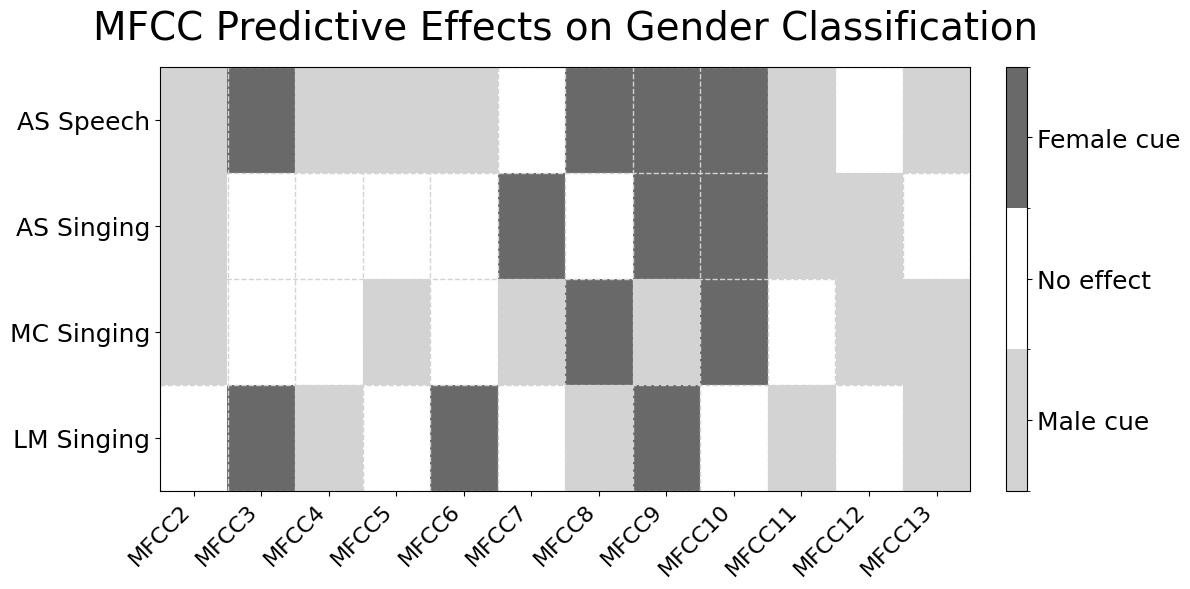

In [31]:
# =========================================================
# MFCC predictive effects
# -1 = male cue
#  0 = no effect
# +1 = female cue
# =========================================================

effects = np.array([
    [-1,  1, -1, -1, -1,  0,  1,  1,  1, -1,  0, -1],  # AS Speech
    [-1,  0,  0,  0,  0,  1,  0,  1,  1, -1, -1,  0],  # AS Singing
    [-1,  0,  0, -1,  0, -1,  1, -1,  1,  0, -1, -1],  # MC Singing
    [ 0,  1, -1,  0,  1,  0, -1,  1,  0, -1,  0, -1],  # LM Singing
])

datasets = [
    "AS Speech",
    "AS Singing",
    "MC Singing",
    "LM Singing"
]

mfcc_labels = [f"MFCC{i}" for i in range(2, 14)]

# =========================================================
# Grayscale colormap
# light gray  = male cue
# white       = no effect
# dark gray   = female cue
# =========================================================

cmap = ListedColormap([
    "lightgray",  # male cue
    "white",      # no effect
    "dimgray"     # female cue
])

bounds = [-1.5, -0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

# =========================================================
# Plot
# =========================================================

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    effects,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

# Axis labels
ax.set_xticks(np.arange(len(mfcc_labels)))
ax.set_xticklabels(
    mfcc_labels,
    rotation=45,
    ha="right",
    fontsize=16
)

ax.set_yticks(np.arange(len(datasets)))
ax.set_yticklabels(
    datasets,
    fontsize=18
)

# Title
ax.set_title(
    "MFCC Predictive Effects on Gender Classification",
    fontsize=28,
    pad=20
)

# =========================================================
# Gridlines
# =========================================================

ax.set_xticks(
    np.arange(-0.5, len(mfcc_labels), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(datasets), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="lightgray",
    linestyle="--",
    linewidth=1
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# =========================================================
# Colorbar legend
# =========================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[-1, 0, 1],
    fraction=0.045,
    pad=0.04
)

cbar.ax.set_yticklabels([
    "Male cue",
    "No effect",
    "Female cue"
])

cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.show()